In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

processed_path = Path("/Users/carlasequero/Desktop/trabajo-fin-master/solution/data/processed_data_no_duplicates.npz")

data = np.load(processed_path)

print(data.files)

['X_train', 'X_val', 'X_test', 'X_id_train', 'X_id_val', 'X_id_test', 'X_err_train', 'X_err_val', 'X_err_test', 'y_train', 'y_val', 'y_test', 'y_id_train', 'y_id_val', 'y_id_test', 'y_ivar_train', 'y_ivar_val', 'y_ivar_test', 'gaia_wavelength', 'sdss_wavelength']


In [2]:
# Datos de entrada Gaia
X_train = data["X_train"]
X_val = data["X_val"]
X_test = data["X_test"]

# Errores de Gaia
X_err_train = data["X_err_train"]
X_err_val = data["X_err_val"]
X_err_test = data["X_err_test"]

# IDs de Gaia
X_id_train = data["X_id_train"]
X_id_val = data["X_id_val"]
X_id_test = data["X_id_test"]

# Datos objetivo SDSS
y_train = data["y_train"]
y_val = data["y_val"]
y_test = data["y_test"]

# IDs de SDSS
y_id_train = data["y_id_train"]
y_id_val = data["y_id_val"]
y_id_test = data["y_id_test"]

# Ivar de SDSS
y_ivar_train = data["y_ivar_train"]
y_ivar_val = data["y_ivar_val"]
y_ivar_test = data["y_ivar_test"]

# Longitudes de onda
gaia_wavelength = data["gaia_wavelength"]
sdss_wavelength = data["sdss_wavelength"]

In [11]:
X = np.concatenate(
    [X_train, X_val, X_test],
    axis=0
)

X_err = np.concatenate(
    [X_err_train, X_err_val, X_err_test],
    axis=0
)

X_id = np.concatenate(
    [X_id_train, X_id_val, X_id_test],
    axis=0
)

y = np.concatenate(
    [y_train, y_val, y_test],
    axis=0
)

y_ivar = np.concatenate(
    [y_ivar_train, y_ivar_val, y_ivar_test],
    axis=0
)

y_id = np.concatenate(
    [y_id_train, y_id_val, y_id_test],
    axis=0
)

In [9]:
def plot_random_examples(
    X,
    X_err,
    y,
    y_ivar,
    gaia_wavelength,
    sdss_wavelength,
    gaia_ID,
    sdss_ID,
    n_examples=5,
    seed=None
):
    rng = np.random.default_rng(seed)
    n_samples = X.shape[0]

    random_indices = rng.choice(
        n_samples,
        size=min(n_examples, n_samples),
        replace=False
    )

    for idx in random_indices:

        # Puntos válidos de SNR de gaia
        valid_gaia = (
            np.isfinite(X_err[idx])
            & (X_err[idx] > 0)
        )

        # Puntos válidos de SNR de SDSS
        valid_sdss = (
            np.isfinite(y_ivar[idx])
            & (y_ivar[idx] > 0)
        )

        # Cálculo del error de SDSS a partir de IVAR
        sdss_error = np.full(
            y[idx].shape,
            np.nan,
            dtype=float
        )

        sdss_error[valid_sdss] = (
            1.0 / np.sqrt(y_ivar[idx][valid_sdss])
        )

        gaia_snr = np.nanmedian(
            X[idx][valid_gaia]
            / X_err[idx][valid_gaia]
        )

        sdss_snr = np.nanmedian(
            y[idx][valid_sdss]
            * np.sqrt(y_ivar[idx][valid_sdss])
        )

        plt.figure(figsize=(11, 5))

        # Espectro SDSS
        plt.plot(
            sdss_wavelength[valid_sdss],
            y[idx][valid_sdss],
            label=f"Espectro de SDSS",
            linewidth=1.2
        )

        # Banda de error SDSS: flujo +- error
        plt.fill_between(
            sdss_wavelength[valid_sdss],
            y[idx][valid_sdss] - sdss_error[valid_sdss],
            y[idx][valid_sdss] + sdss_error[valid_sdss],
            alpha=0.20,
            label="Error SDSS"
        )

        # Espectro Gaia
        plt.plot(
            gaia_wavelength[valid_gaia],
            X[idx][valid_gaia],
            label=f"Espectro de Gaia",
            linewidth=1.2,
            alpha=0.8
        )

        # Banda de error Gaia: flujo +- error
        plt.fill_between(
            gaia_wavelength[valid_gaia],
            X[idx][valid_gaia] - X_err[idx][valid_gaia],
            X[idx][valid_gaia] + X_err[idx][valid_gaia],
            alpha=0.20,
            label="Error Gaia"
        )

        plt.xlabel("Longitud de onda [Å]")
        plt.ylabel("Flujo")

        plt.title(
            f"Gaia source_id: {gaia_ID[idx]} | "
            f"SDSS obj_id: {sdss_ID[idx]}\n"
        )

        plt.legend()
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

    return random_indices

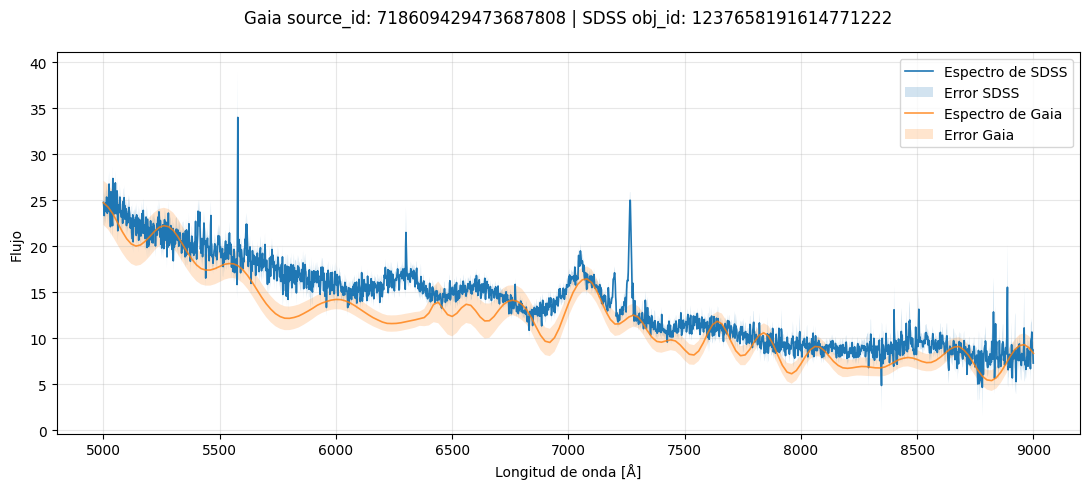

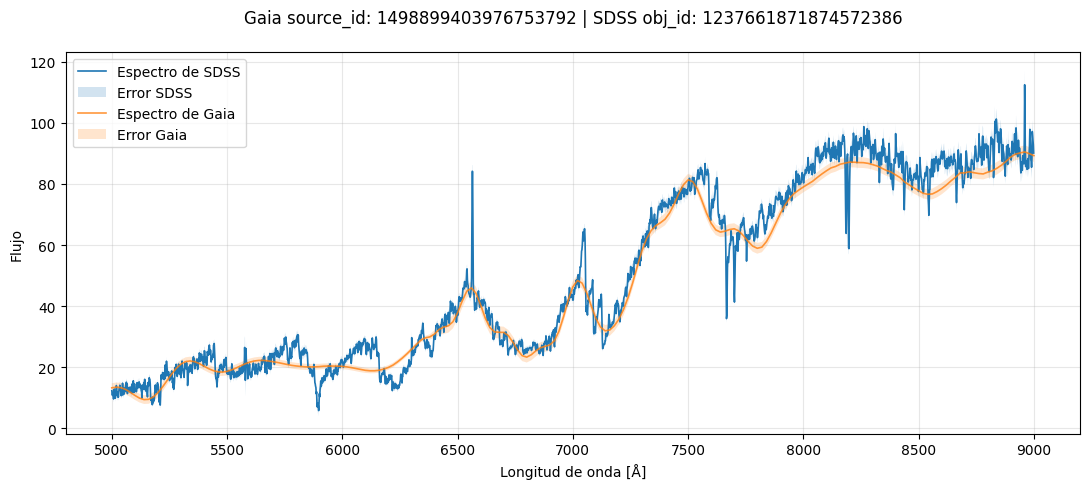

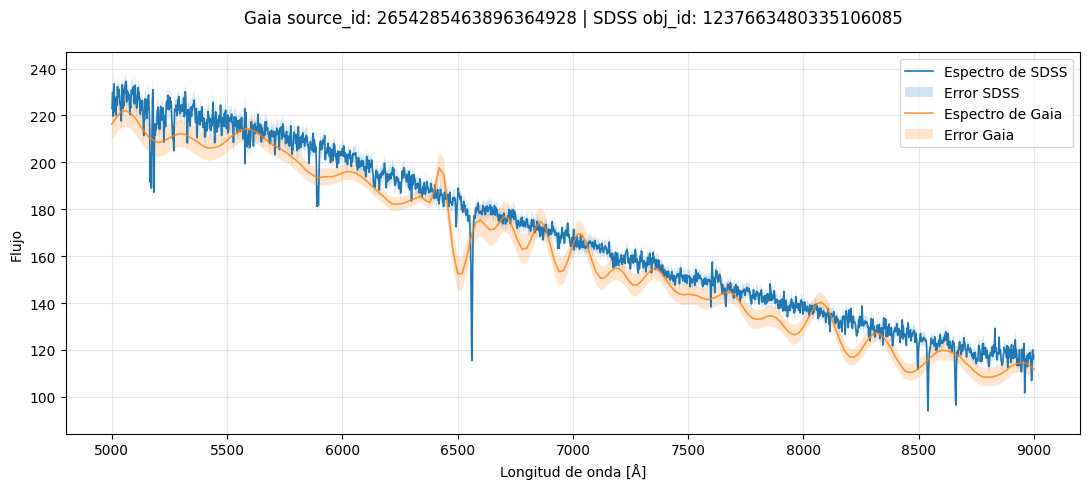

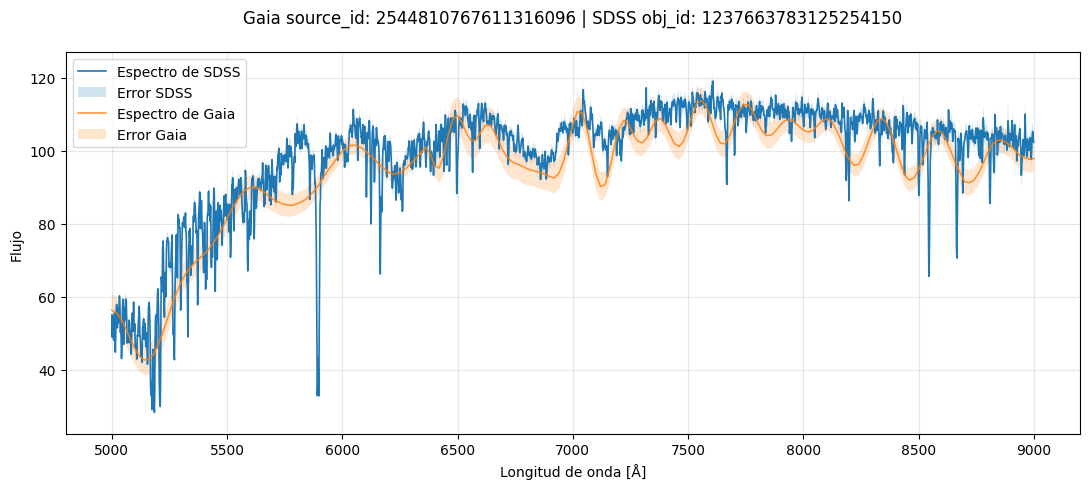

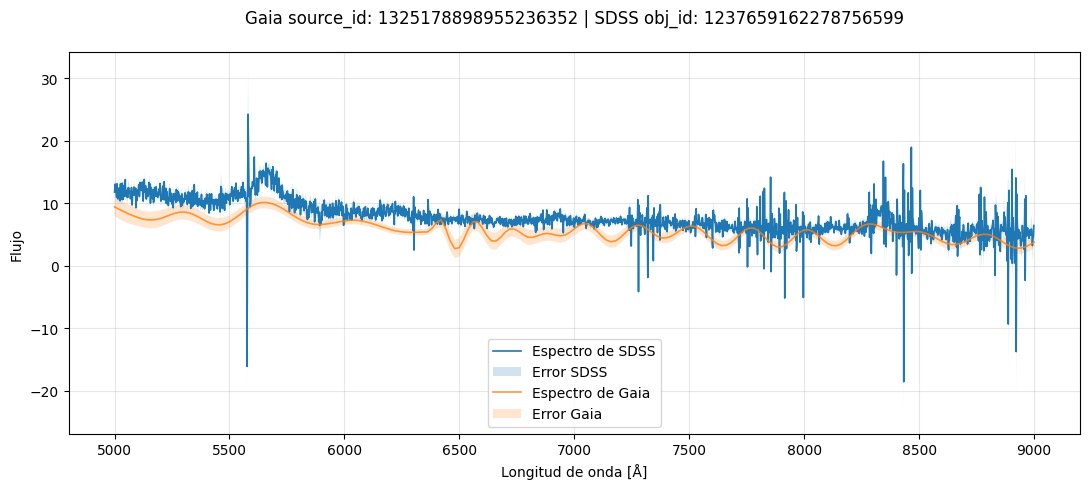

In [12]:
random_indices = plot_random_examples(
    X=X,
    X_err=X_err,
    y=y,
    y_ivar=y_ivar,
    gaia_wavelength=gaia_wavelength,
    sdss_wavelength=sdss_wavelength,
    gaia_ID=X_id,
    sdss_ID=y_id,
    n_examples=5,
    seed=23 #42
)

Estudiemos el error de SDSS y Gaia. Compararemos ambos instrumentos.

In [13]:
valid_gaia_pixel = (
    np.isfinite(X)
    & np.isfinite(X_err)
    & (X_err > 0)
)

gaia_snr_pixel = np.full(X.shape, np.nan, dtype=float)

gaia_snr_pixel[valid_gaia_pixel] = (
    X[valid_gaia_pixel]
    / X_err[valid_gaia_pixel]
)

# SNR media
gaia_snr = np.nanmedian(gaia_snr_pixel, axis=1)


# Error relativo = error absoluto / flujo
gaia_relative_error_pixel = np.full(X.shape, np.nan, dtype=float)

valid_gaia_relative_error = (
    valid_gaia_pixel
    & (np.abs(X) > 0)
)

gaia_relative_error_pixel[valid_gaia_relative_error] = (
    X_err[valid_gaia_relative_error]
    / np.abs(X[valid_gaia_relative_error])
)

gaia_relative_error = np.nanmedian(
    gaia_relative_error_pixel,
    axis=1
)


valid_sdss_pixel = (
    np.isfinite(y)
    & np.isfinite(y_ivar)
    & (y_ivar > 0)
)

# Error absoluto SDSS: sigma = 1 / sqrt(ivar)
sdss_error_pixel = np.full(y.shape, np.nan, dtype=float)

sdss_error_pixel[valid_sdss_pixel] = (
    1.0 / np.sqrt(y_ivar[valid_sdss_pixel])
)

# SNR SDSS: flujo / error = flujo * sqrt(ivar)
sdss_snr_pixel = np.full(y.shape, np.nan, dtype=float)

sdss_snr_pixel[valid_sdss_pixel] = (
    y[valid_sdss_pixel]
    * np.sqrt(y_ivar[valid_sdss_pixel])
)

sdss_snr = np.nanmedian(sdss_snr_pixel, axis=1)


# Error relativo SDSS
sdss_relative_error_pixel = np.full(y.shape, np.nan, dtype=float)

valid_sdss_relative_error = (
    valid_sdss_pixel
    & (np.abs(y) > 0)
)

sdss_relative_error_pixel[valid_sdss_relative_error] = (
    sdss_error_pixel[valid_sdss_relative_error]
    / np.abs(y[valid_sdss_relative_error])
)

sdss_relative_error = np.nanmedian(
    sdss_relative_error_pixel,
    axis=1
)

In [14]:
print("SNR mediano del conjunto")
print(f"Gaia: {np.nanmedian(gaia_snr):.3f}")
print(f"SDSS: {np.nanmedian(sdss_snr):.3f}")

print("\nError relativo mediano del conjunto")
print(f"Gaia: {np.nanmedian(gaia_relative_error):.3f}")
print(f"SDSS: {np.nanmedian(sdss_relative_error):.3f}")

SNR mediano del conjunto
Gaia: 20.039
SDSS: 34.765

Error relativo mediano del conjunto
Gaia: 0.050
SDSS: 0.029


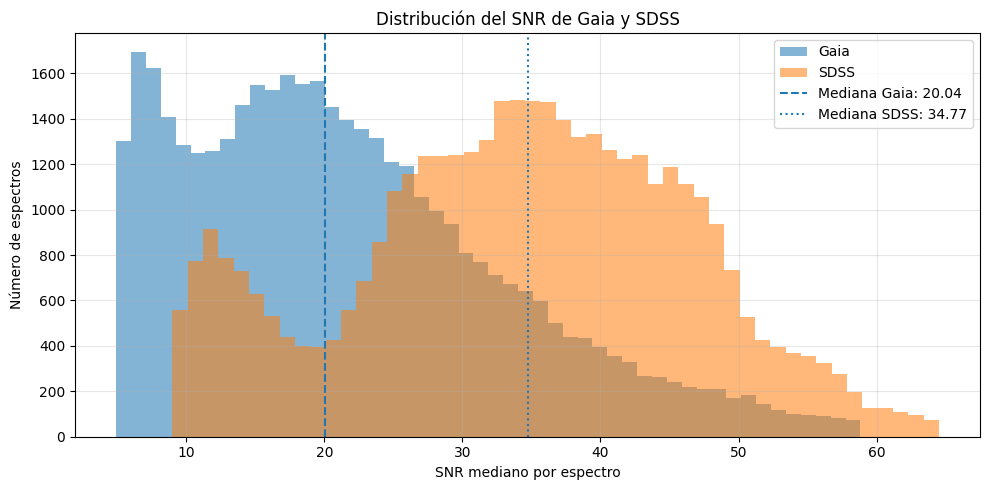

In [15]:
gaia_snr_limit = np.nanpercentile(
    gaia_snr[np.isfinite(gaia_snr)],
    99
)

sdss_snr_limit = np.nanpercentile(
    sdss_snr[np.isfinite(sdss_snr)],
    99
)

gaia_snr_plot = gaia_snr[
    np.isfinite(gaia_snr)
    & (gaia_snr >= 0)
    & (gaia_snr <= gaia_snr_limit)
]

sdss_snr_plot = sdss_snr[
    np.isfinite(sdss_snr)
    & (sdss_snr >= 0)
    & (sdss_snr <= sdss_snr_limit)
]

plt.figure(figsize=(10, 5))

plt.hist(
    gaia_snr_plot,
    bins=50,
    alpha=0.55,
    label="Gaia"
)

plt.hist(
    sdss_snr_plot,
    bins=50,
    alpha=0.55,
    label="SDSS"
)

plt.axvline(
    np.nanmedian(gaia_snr),
    linestyle="--",
    label=f"Mediana Gaia: {np.nanmedian(gaia_snr):.2f}"
)

plt.axvline(
    np.nanmedian(sdss_snr),
    linestyle=":",
    label=f"Mediana SDSS: {np.nanmedian(sdss_snr):.2f}"
)

plt.xlabel("SNR mediano por espectro")
plt.ylabel("Número de espectros")
plt.title("Distribución del SNR de Gaia y SDSS")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

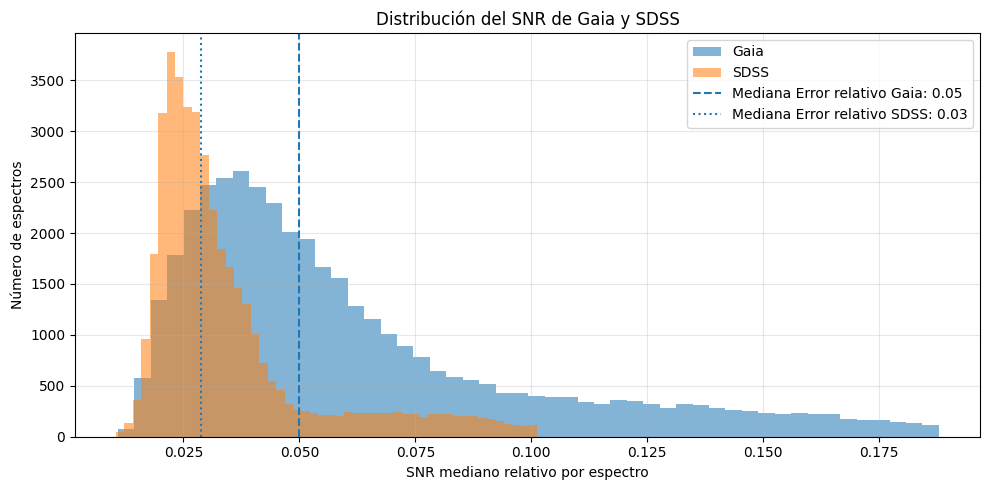

In [21]:
gaia_snr_limit = np.nanpercentile(
    gaia_relative_error[np.isfinite(gaia_relative_error)],
    99
)

sdss_snr_limit = np.nanpercentile(
    sdss_relative_error[np.isfinite(sdss_relative_error)],
    99
)

gaia_snr_plot = gaia_relative_error[
    np.isfinite(gaia_relative_error)
    & (gaia_relative_error >= 0)
    & (gaia_relative_error <= gaia_snr_limit)
]

sdss_snr_plot = sdss_relative_error[
    np.isfinite(sdss_relative_error)
    & (sdss_relative_error >= 0)
    & (sdss_relative_error <= sdss_snr_limit)
]

plt.figure(figsize=(10, 5))

plt.hist(
    gaia_snr_plot,
    bins=50,
    alpha=0.55,
    label="Gaia"
)

plt.hist(
    sdss_snr_plot,
    bins=50,
    alpha=0.55,
    label="SDSS"
)

plt.axvline(
    np.nanmedian(gaia_relative_error),
    linestyle="--",
    label=f"Mediana Error relativo Gaia: {np.nanmedian(gaia_relative_error):.2f}"
)

plt.axvline(
    np.nanmedian(sdss_relative_error),
    linestyle=":",
    label=f"Mediana Error relativo SDSS: {np.nanmedian(sdss_relative_error):.2f}"
)

plt.xlabel("SNR mediano relativo por espectro")
plt.ylabel("Número de espectros")
plt.title("Distribución del SNR de Gaia y SDSS")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

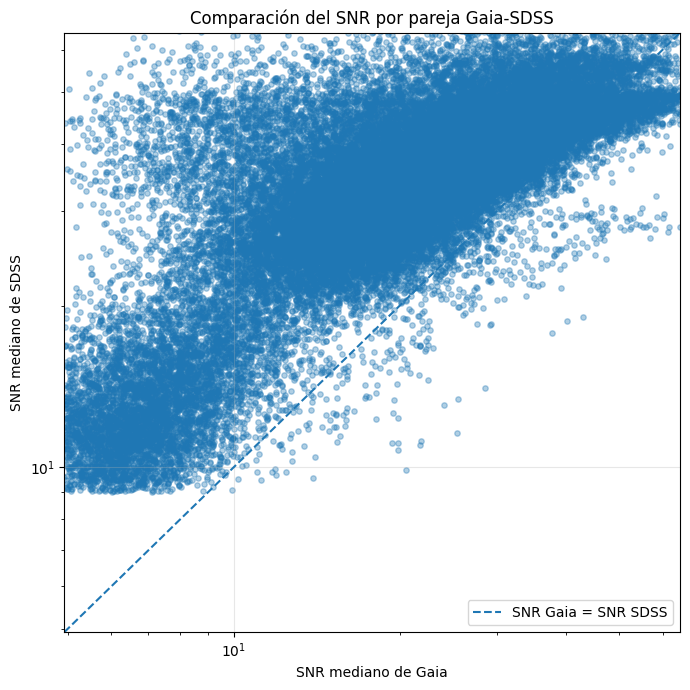

In [18]:
valid_comparison = (
    np.isfinite(gaia_snr)
    & np.isfinite(sdss_snr)
    & (gaia_snr > 0)
    & (sdss_snr > 0)
)

gaia_snr_comparison = gaia_snr[valid_comparison]
sdss_snr_comparison = sdss_snr[valid_comparison]

minimum_snr = min(
    np.nanmin(gaia_snr_comparison),
    np.nanmin(sdss_snr_comparison)
)

maximum_snr = max(
    np.nanpercentile(gaia_snr_comparison, 99),
    np.nanpercentile(sdss_snr_comparison, 99)
)

plt.figure(figsize=(7, 7))

plt.scatter(
    gaia_snr_comparison,
    sdss_snr_comparison,
    s=15,
    alpha=0.35
)

# Línea en la que ambos instrumentos tendrían el mismo SNR
plt.plot(
    [minimum_snr, maximum_snr],
    [minimum_snr, maximum_snr],
    linestyle="--",
    label="SNR Gaia = SNR SDSS"
)

plt.xscale("log")
plt.yscale("log")

plt.xlim(minimum_snr, maximum_snr)
plt.ylim(minimum_snr, maximum_snr)

plt.xlabel("SNR mediano de Gaia")
plt.ylabel("SNR mediano de SDSS")
plt.title("Comparación del SNR por pareja Gaia-SDSS")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

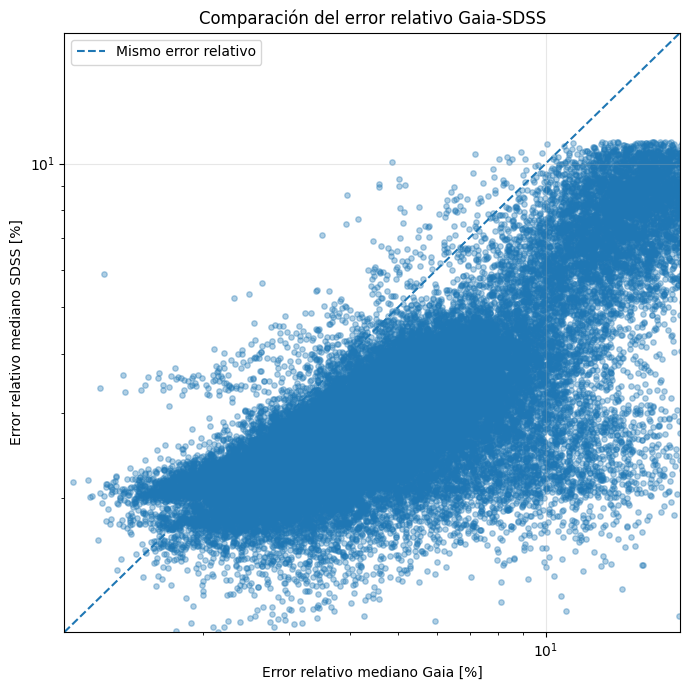

In [17]:
valid_relative_comparison = (
    np.isfinite(gaia_relative_error)
    & np.isfinite(sdss_relative_error)
    & (gaia_relative_error > 0)
    & (sdss_relative_error > 0)
)

gaia_error_comparison = (
    100 * gaia_relative_error[valid_relative_comparison]
)

sdss_error_comparison = (
    100 * sdss_relative_error[valid_relative_comparison]
)

minimum_error = min(
    np.nanmin(gaia_error_comparison),
    np.nanmin(sdss_error_comparison)
)

maximum_error = max(
    np.nanpercentile(gaia_error_comparison, 99),
    np.nanpercentile(sdss_error_comparison, 99)
)

plt.figure(figsize=(7, 7))

plt.scatter(
    gaia_error_comparison,
    sdss_error_comparison,
    s=15,
    alpha=0.35
)

plt.plot(
    [minimum_error, maximum_error],
    [minimum_error, maximum_error],
    linestyle="--",
    label="Mismo error relativo"
)

plt.xscale("log")
plt.yscale("log")

plt.xlim(minimum_error, maximum_error)
plt.ylim(minimum_error, maximum_error)

plt.xlabel("Error relativo mediano Gaia [%]")
plt.ylabel("Error relativo mediano SDSS [%]")
plt.title("Comparación del error relativo Gaia-SDSS")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

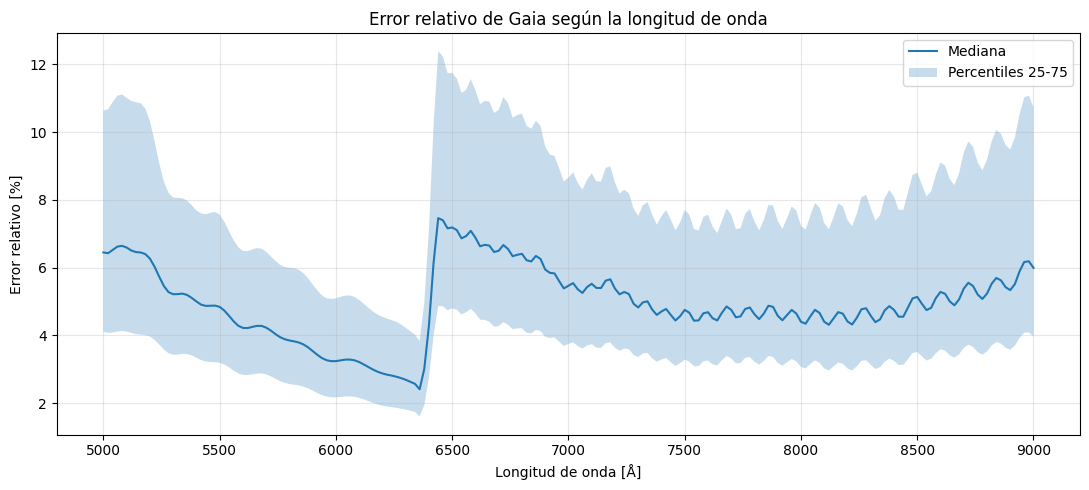

In [19]:
gaia_error_median_wave = np.nanmedian(
    gaia_relative_error_pixel,
    axis=0
)

gaia_error_p25_wave = np.nanpercentile(
    gaia_relative_error_pixel,
    25,
    axis=0
)

gaia_error_p75_wave = np.nanpercentile(
    gaia_relative_error_pixel,
    75,
    axis=0
)

plt.figure(figsize=(11, 5))

plt.plot(
    gaia_wavelength,
    100 * gaia_error_median_wave,
    label="Mediana"
)

plt.fill_between(
    gaia_wavelength,
    100 * gaia_error_p25_wave,
    100 * gaia_error_p75_wave,
    alpha=0.25,
    label="Percentiles 25-75"
)

plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Error relativo [%]")
plt.title("Error relativo de Gaia según la longitud de onda")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

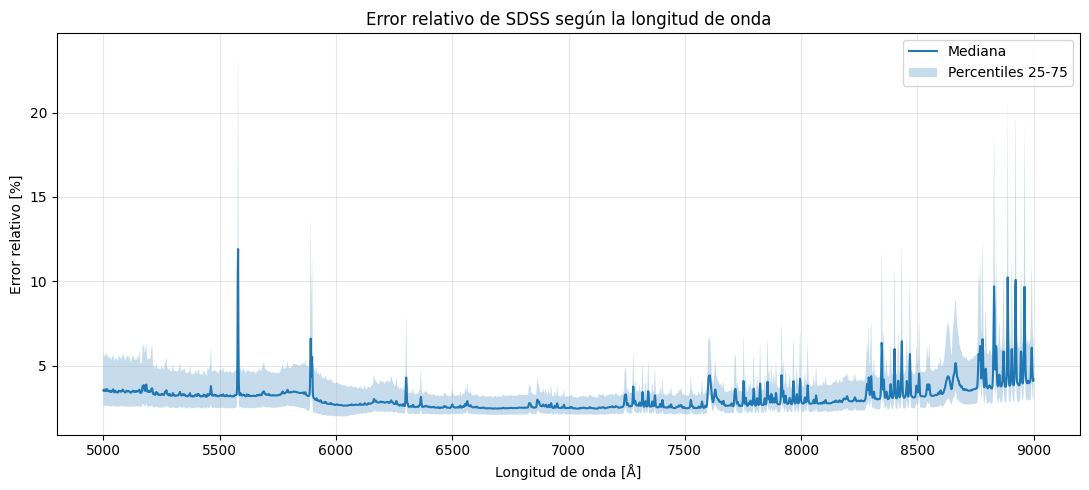

In [20]:
sdss_error_median_wave = np.nanmedian(
    sdss_relative_error_pixel,
    axis=0
)

sdss_error_p25_wave = np.nanpercentile(
    sdss_relative_error_pixel,
    25,
    axis=0
)

sdss_error_p75_wave = np.nanpercentile(
    sdss_relative_error_pixel,
    75,
    axis=0
)

plt.figure(figsize=(11, 5))

plt.plot(
    sdss_wavelength,
    100 * sdss_error_median_wave,
    label="Mediana"
)

plt.fill_between(
    sdss_wavelength,
    100 * sdss_error_p25_wave,
    100 * sdss_error_p75_wave,
    alpha=0.25,
    label="Percentiles 25-75"
)

plt.xlabel("Longitud de onda [Å]")
plt.ylabel("Error relativo [%]")
plt.title("Error relativo de SDSS según la longitud de onda")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()